# Homework Answer

* Họ và tên: Nguyễn Vạn Phúc Huy 
* MSSV: 23110163

1. Choose an external image (from the internet or your computer) and complete all the above tasks.

2. Understanding BINS in Histograms
    - Explain the concept of “bins” in the context of image histograms.
    - Describe how bins affect the construction and visualization of histograms

3. Justification for Using BINS
    - Discuss why histograms are divided into bins instead of showing individual pixel intensity values.
    - Explain how binning influences the accuracy and interpretability of histograms in image analysis.


4. Gamma and Logarithmic Correction
    - Apply Gamma Correction and Logarithmic Transformation to improve the image contrast.
    - Using cv2 instead of skimage in order to takes an image and a gamma value then returning the gamma-corrected result.
    - Write a Python function that takes an image and a gamma value and returns the gamma-corrected result without using cv2 or skimage built-in functions.
    - Combine Gamma + Logarithmic Correction sequentially. What happens if you apply Log → Gamma vs Gamma → Log?
    - Write a program to automatically find the optimal gamma value for each image based on:

      (a) The standard deviation of the gamma-corrected image.

      (b) The Shannon entropy of the gamma-corrected image.

      💡Hint: Iterate gamma values from 0.3 → 3.0, and choose the one that yields the highest contrast or entropy.

5. Histogram Equalization in HSV Color Space:
    - Apply histogram equalization independently on all three HSV channels (Hue, Saturation, Value) and display the result.
    - Apply histogram equalization only on the S (Saturation) and V (Value) channels to enhance image quality while preserving hue.
    - Plot and compare the histograms of the original image versus the equalized image, analyzing their visual differences.
    - Implement a function to perform histogram matching between two images:
      → one as the source and another as the reference.

      💡 Hint: You may use cv2.calcHist, cv2.LUT(), or skimage.exposure.match_histograms.

6. Create a binary mask using the following approaches (Please choose another external image and indicate whether the object can be separated or not.):
    - Based on a specific color channel (R, G, or B) condition.
    - Based on intensity thresholds in HSV channels (Hue, Saturation, Value).
    - Based on combined conditions (e.g., R > 200 AND G < 50).

    Apply the mask to the original image in order to extract the target object.

7. Report
    * Display the original image and all processed results (after each transformation).
    * Provide a brief commentary describing and comparing the visual differences observed between the methods.

# Note: mặc định tất cả hằng số c đều là c = 1

## 1. Choose an external image (from the internet or your computer) and complete all the above tasks

Import Libs

In [68]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import os
import gdown
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from cv2 import imwrite, imread
from skimage import data, img_as_float
from skimage import exposure

Getting Image

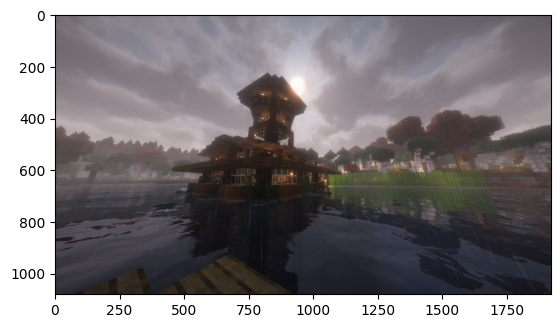

In [69]:
newImg_BGR = cv2.imread('base.png')
newImg_RGB = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2RGB)

plt.imshow(newImg_RGB)

## 2. Understanding BINS in Histograms
> Explain the concept of “bins” in the context of image histograms.


Trong histogram "bin" có được xem như là "khoảng" (là phạm vi các giá trị liên tục với nhau). Với histogram trong ảnh thì mỗi bin có thể là các giá trị "khoảng" màu từ 0 -> 255 đối với ảnh RGB, còn với ảnh grayscale là các "khoảng" giá trị cường độ 0 -> 1

vd như là: Cho ảnh có dải giá trị từ 0 đến 255 (8 bit) thì mỗi bin sẽ đại diện cho các giá trị liên tiếp (như là 0-31, 32-63...)

--> Các pixel của ảnh sẽ được "bỏ vô/ gán" vào các bin tuỳ theo giá trị của chúng để dễ trực quan và xử lý hơn


> Describe how bins affect the construction and visualization of histograms

Cấu trúc (Construction):

+ Trục Ox: Ứng với mỗi bin trên trục hoành là một khoảng cường độ (vd ở trên: 0–31, 31–63...)
+ Trục Oy: Thể hiện số lượng pixel thuộc trong mỗi bin (tần suất/cường độ xuất hiện)

Trực quan (Visualization):
+ Số lượng bin (khoảng) ít sẽ gom các giá trị lại thành nhóm lớn, làm biểu đồ trông "thô" nhưng sẽ dễ nhìn hơn. 
+ Số lượng bin (khoảng) nhiều sẽ cho biểu đồ chi tiết hơn, thể hiện rõ các đặc trưng của ảnh nhưng có thể bị "nhiễu"  

Việc chọn số lượng bin phù hợp giúp cân bằng giữa chi tiết và dễ quan sát.​​


## 3. Justification for Using BINS
> Discuss why histograms are divided into bins instead of showing individual pixel intensity values.

Ảnh hiện nay thường có độ phân giải từ hàng trăm nghìn thậm chí hàng triệu pixel (giống như là  1080p, 2k, 4k, 8k.... hiện nay) với mỗi pixel mang giá trị cường độ (0-255 với ảnh xám 8 bit).
Nếu vẽ histogram với từng giá trị riêng lẻ (256 cột) thì histogram sẽ rất chi tiết nhưng dễ bị nhiễu và rối, khi đó việc phân tích tổng thể trở nên phức tạp và khó khăn, nhất là với ảnh màu/ phân giải cao hơn (do càng nhiều màu/ phân giải cao hơn thì càng có nhiều pixel/ dữ liệu cần được giải quyết)
=> So sánh từng giá trị pixel giữa các ảnh sẽ đòi hỏi quá nhiều tài nguyên để xử lý




> Explain how binning influences the accuracy and interpretability of histograms in image analysis.

Khi gộp pixel vào các khoảng (bin) thì lượng thông tin và dữ liệu cần xử lý giảm đáng kể. Việc nhóm dữ liệu vào nhiều bin giúp hình dạng tổng thể của histogram rõ ràng, dễ quan sát xu hướng chính (như là check xem là ảnh có vùng tối, trung tính, hoặc sáng chiếm ưu thế)
Hơn nữa bin rộng sẽ làm trơn histogram giúp giảm nhiễu, còn bin hẹp sẽ cho chi tiết cao nhưng dễ bị ảnh hưởng bởi biến động ngẫu nhiên hoặc điểm bất thường, ngoại lai (outlier).​...

Việc cân bằng độ chính xác và khả năng phân tích có thể được tóm lại như sau:

 + Quá ít bin (bin khi này sẽ rộng): histogram sẽ phản ánh tổng quát, có thể mất những chi tiết hoặc dữ liệu các đỉnh nhỏ đặc trưng.

 + Quá nhiều bin (bin khi này sẽ hẹp): histogram quá phân mảnh, khó quan sát xu hướng và dễ bị méo do nhiễu.

=> Khi các ảnh được phân tích cùng một hệ bin chuẩn, việc so sánh, phân loại, tính toán trở nên nhanh chóng hơn rất nhiều so với so sánh từng pixel riêng lẻ hoặc từng tổ hợp màu cụ thể.​

## 4. Gamma and Logarithmic Correction
- Apply Gamma Correction and Logarithmic Transformation to improve the image contrast.
- Using cv2 instead of skimage in order to takes an image and a gamma value then returning the gamma-corrected result.
- Write a Python function that takes an image and a gamma value and returns the gamma-corrected result without using cv2 or skimage built-in functions.
- Combine Gamma + Logarithmic Correction sequentially. What happens if you apply Log → Gamma vs Gamma → Log?
- Write a program to automatically find the optimal gamma value for each image based on:

  (a) The standard deviation of the gamma-corrected image.

  (b) The Shannon entropy of the gamma-corrected image.

  💡Hint: Iterate gamma values from 0.3 → 3.0, and choose the one that yields the highest contrast or entropy.


Apply Gamma Correction and Logarithmic Transformation to improve the image contrast.

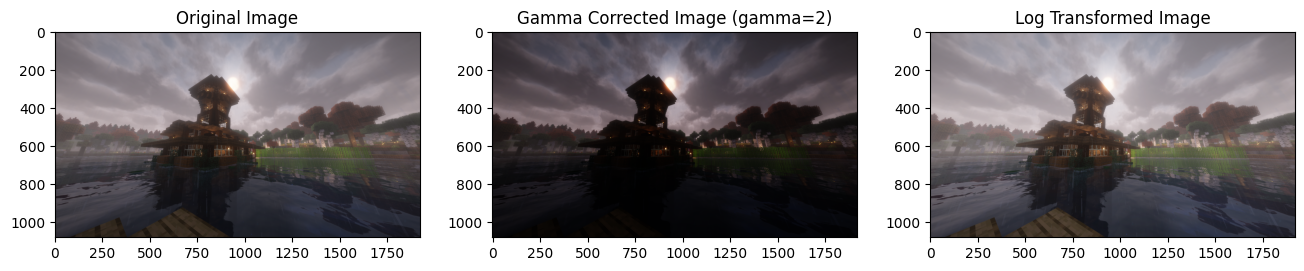

In [ ]:

def gammaCorrection(image, gamma):
    correctedImg = exposure.adjust_gamma(image, gamma)
    return correctedImg

def logTransformation(image, gain=1):
    logImg = exposure.adjust_log(image, gain=gain)
    return logImg

gammaCorrected_Img = gammaCorrection(newImg_RGB, 2)
logTransformed_Img = logTransformation(newImg_RGB)

# Display the results
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(newImg_RGB)
plt.subplot(1, 3, 2)
plt.title('Gamma Corrected Image (gamma=2)')
plt.imshow(gammaCorrected_Img)
plt.subplot(1, 3, 3)
plt.title('Log Transformed Image')
plt.imshow(logTransformed_Img)
plt.show()



Using cv2 instead of skimage in order to takes an image and a gamma value then returning the gamma-corrected result.

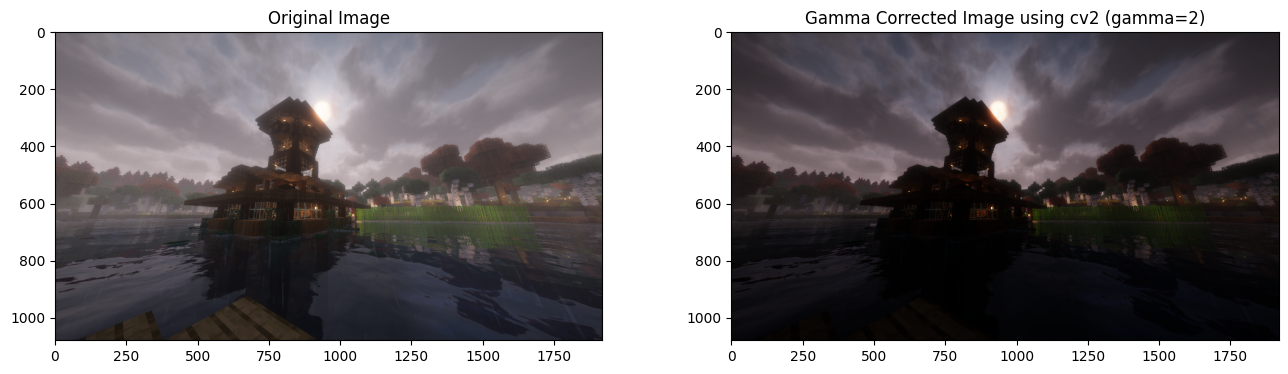

In [71]:
# Công thức tổng quát của gamma correction là: s = c * r^γ

def gammaCorrection_cv2(image, gamma):
    # Lấy dữ liệu ảnh và đưa về dạng [0, 1] để áp dụng công thức
    imageArray = np.array(image, dtype=np.float32) / 255.0
    
    # Áp dụng công thức
    correctedImg = cv2.pow(imageArray, gamma)
    # Chuyen về dạng [0, 255]
    correctedImg = np.uint8(correctedImg * 255)
    return correctedImg

gammaCorrected_Img_cv2 = gammaCorrection_cv2(newImg_RGB, 2)


# Display the results
plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(newImg_RGB)
plt.subplot(1, 2, 2)
plt.title('Gamma Corrected Image using cv2 (gamma=2)')
plt.imshow(gammaCorrected_Img_cv2)
plt.show()



Write a Python function that takes an image and a gamma value and returns the gamma-corrected result without using cv2 or skimage built-in functions.

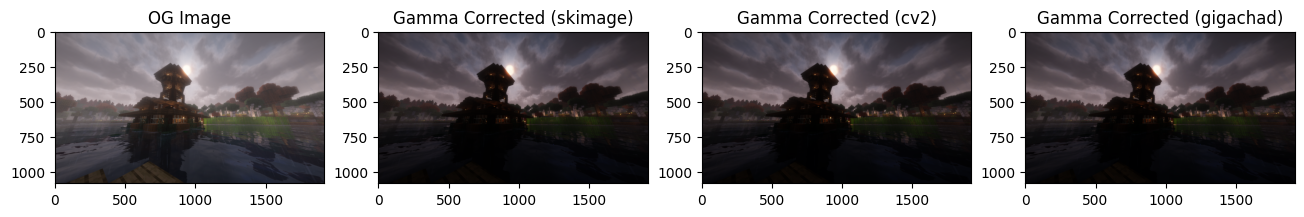

In [ ]:

def gammaCorrection_gigachad(image, gamma):
    # Lấy dữ liệu ảnh và đưa về dạng [0, 1] để áp dụng công thức
    imageArray = np.array(image, dtype=np.float32) / 255.0
    
    # Áp dụng công thức
    correctedImg = np.power(imageArray, gamma)
    
    # Chuyen về dạng [0, 255]
    correctedImg = np.uint8(correctedImg * 255)
    return correctedImg

gammaCorrected_Img_gigachad = gammaCorrection_gigachad(newImg_RGB, 2)

# Hiển thị kết quả
# show 4 images: original, skimage gamma corrected, cv2 gamma corrected, gigachad gamma corrected
plt.figure(figsize=(16,4))
plt.subplot(1,4,1)
plt.title('OG Image')
plt.imshow(newImg_RGB)
plt.subplot(1,4,2)
plt.title('Gamma Corrected (skimage)')
plt.imshow(gammaCorrected_Img)
plt.subplot(1,4,3)
plt.title('Gamma Corrected (cv2)')
plt.imshow(gammaCorrected_Img_cv2)
plt.subplot(1,4,4)
plt.title('Gamma Corrected (gigachad)')
plt.imshow(gammaCorrected_Img_gigachad)
plt.show()

Combine Gamma + Logarithmic Correction sequentially. What happens if you apply Log → Gamma vs Gamma → Log?

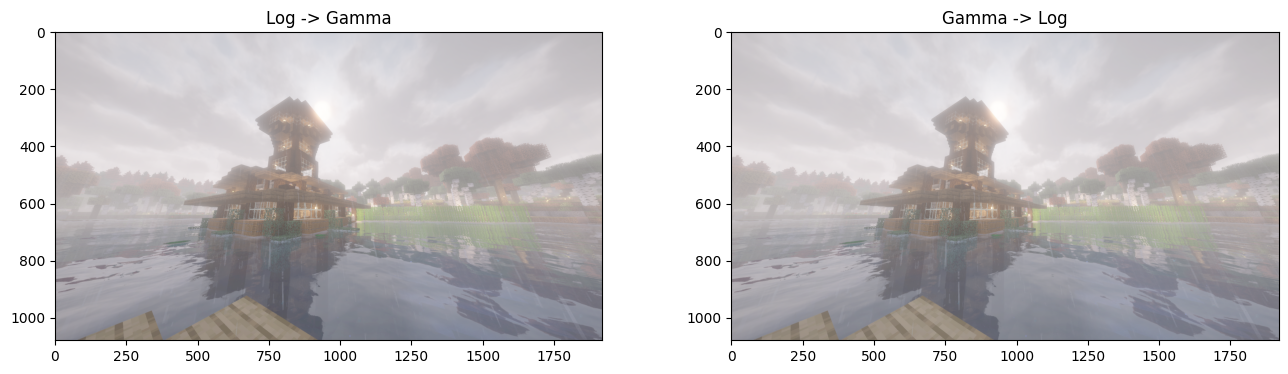

In [ ]:

def combineLogGamma(image, gamma):
    logImg = logTransformation(image)
    logGammaImg = gammaCorrection(logImg, gamma)
    return logGammaImg

def combineGammaLog(image, gamma):
    gammaImg = gammaCorrection(image, gamma)
    gammaLogImg = logTransformation(gammaImg)
    return gammaLogImg

logGamma_Img = combineLogGamma(newImg_RGB, 0.4)
gammaLog_Img = combineGammaLog(newImg_RGB, 0.4)

# show 2 images: log->gamma, gamma->log
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('Log -> Gamma')
plt.imshow(logGamma_Img)
plt.subplot(1,2,2)
plt.title('Gamma -> Log')
plt.imshow(gammaLog_Img)
plt.show()


In [74]:
# Kết quả của hai phương pháp này sẽ khác nhau nếu ta nhìn kỹ ở 2 ảnh log->gamma và gamma->log (dễ thấy nhất khối gỗ ở góc dưới bên trái)
# Khi áp dụng Log → Gamma, hình ảnh đầu ra thường có độ tương phản cao hơn
# Khi áp dụng Gamma → Log, hình ảnh có cảm giác "mờ" hơn và không chi tiết bằng ảnh kia

Write a program to automatically find the optimal gamma value for each image based on:

 - (a) The standard deviation of the gamma-corrected image.

 - (b) The Shannon entropy of the gamma-corrected image.

  💡Hint: Iterate gamma values from 0.3 → 3.0, and choose the one that yields the highest contrast or entropy.

Optimal gamma value: 1.0000000000000002
Maximum standard deviation: 50.62499033794932
Maximum entropy: 7.428942644035181


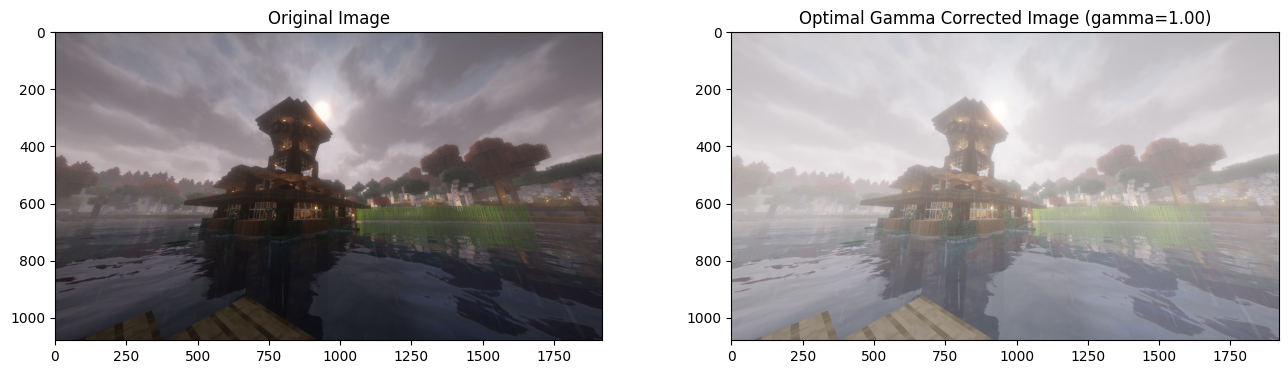

In [ ]:
# Phần lý thuyết thông tin chưa học mà Shannon entropy thuộc về cái đó nên chịu :skull: 
from skimage.measure import shannon_entropy

def findOptimalGamma(image):
    best_gamma = 0.3
    max_std_dev = 0
    max_entropy = 0

    for gamma in np.arange(0.3, 3.0, 0.1):
        gamma_img = gammaCorrection(image, gamma)
        std_dev = np.std(gamma_img)
        entropy = shannon_entropy(gamma_img)

        if std_dev > max_std_dev:
            max_std_dev = std_dev
            best_gamma = gamma

        if entropy > max_entropy:
            max_entropy = entropy
            best_gamma = gamma

    return best_gamma, max_std_dev, max_entropy

optGamma, maxStdDev, maxEntropy = findOptimalGamma(newImg_RGB)
print(f'Optimal gamma value: {optGamma}')
print(f'Maximum standard deviation: {maxStdDev}')
print(f'Maximum entropy: {maxEntropy}')


optGamma_Img = gammaCorrection(logGamma_Img, optGamma)
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(newImg_RGB)
plt.subplot(1,2,2)
plt.title(f'Optimal Gamma Corrected Image (gamma={optGamma:.2f})')
plt.imshow(optGamma_Img)
plt.show()


## 5. Histogram Equalization in HSV Color Space:
- Apply histogram equalization independently on all three HSV channels (Hue, Saturation, Value) and display the result.
- Apply histogram equalization only on the S (Saturation) and V (Value) channels to enhance image quality while preserving hue.
- Plot and compare the histograms of the original image versus the equalized image, analyzing their visual differences.
- Implement a function to perform histogram matching between two images:
  → one as the source and another as the reference.

💡 Hint: You may use cv2.calcHist, cv2.LUT(), or skimage.exposure.match_histograms.

Apply histogram equalization independently on all three HSV channels (Hue, Saturation, Value)

In [ ]:

def histogramEqualization(image):
    hsvImg = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsvImg)

    h_eq = cv2.equalizeHist(h)
    s_eq = cv2.equalizeHist(s)
    v_eq = cv2.equalizeHist(v)

    hsv_eq = cv2.merge([h_eq, s_eq, v_eq])
    rgb_eq = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2RGB)

    return rgb_eq

histEq_Img = histogramEqualization(newImg_RGB)


Apply histogram equalization only on the S (Saturation) and V (Value) channels to enhance image quality while preserving hue.



In [ ]:

def histogramEqualizationSV(image):
    hsvImg = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsvImg)

    s_eq = cv2.equalizeHist(s)
    v_eq = cv2.equalizeHist(v)

    hsv_eq = cv2.merge([h, s_eq, v_eq])
    rgb_eq = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2RGB)

    return rgb_eq

histEqSV_Img = histogramEqualizationSV(newImg_RGB)




Plot and compare the histograms of the original image versus the equalized image, analyzing their visual differences.

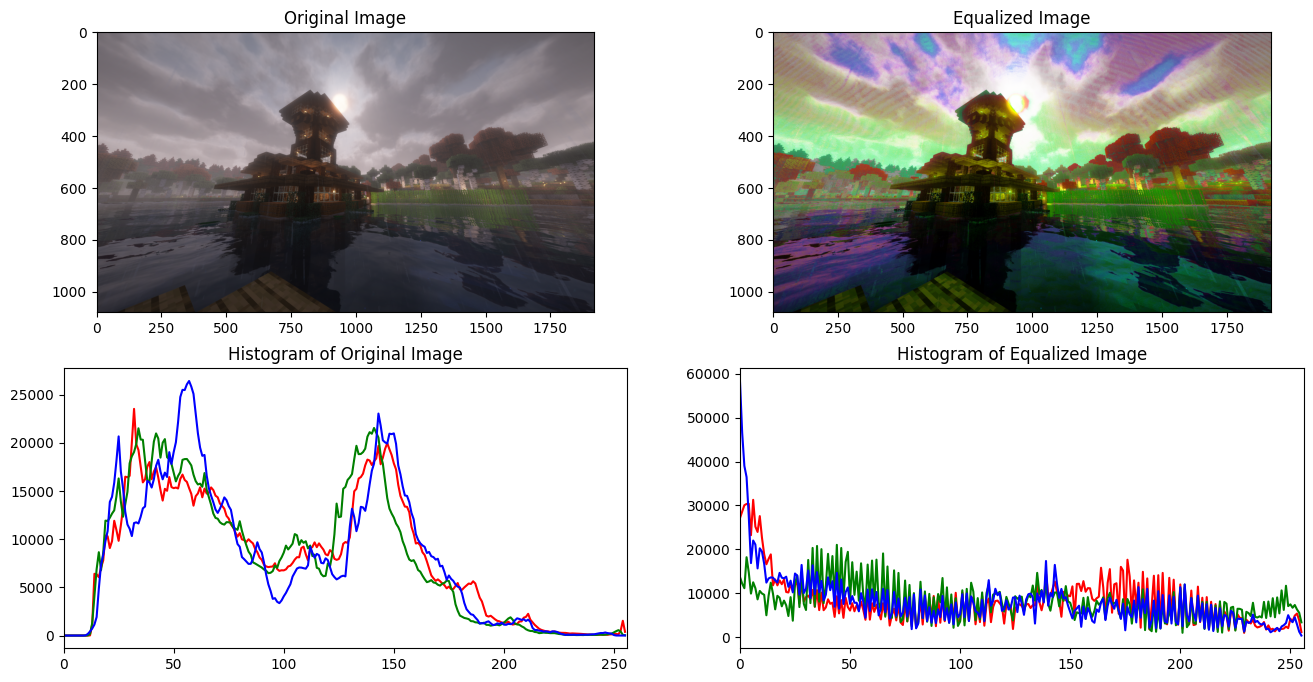

In [ ]:

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.title('Original Image')
plt.imshow(newImg_RGB)

plt.subplot(2, 2, 2)
plt.title('Equalized Image')
plt.imshow(histEq_Img)

plt.subplot(2, 2, 3)
plt.title('Histogram of Original Image')
for i, color in enumerate(['r', 'g', 'b']):
    hist = cv2.calcHist([newImg_RGB], [i], None, [256], [0, 256])
    plt.plot(hist, color=color)
    plt.xlim([0, 256])

plt.subplot(2, 2, 4)
plt.title('Histogram of Equalized Image')
for i, color in enumerate(['r', 'g', 'b']):
    hist = cv2.calcHist([histEq_Img], [i], None, [256], [0, 256])
    plt.plot(hist, color=color)
    plt.xlim([0, 256])

plt.show()

# Nhận xét:
# Histogram của ảnh gốc thường có các vùng tập trung cao và các vùng trống, trong khi histogram của ảnh sau khi cân bằng thường phân bố đều hơn trên toàn bộ dải giá trị cường độ.
# Điều này cho thấy rằng quá trình cân bằng histogram đã giúp cải thiện độ tương phản của ảnh bằng cách mở rộng phạm vi cường độ sử dụng trong ảnh.


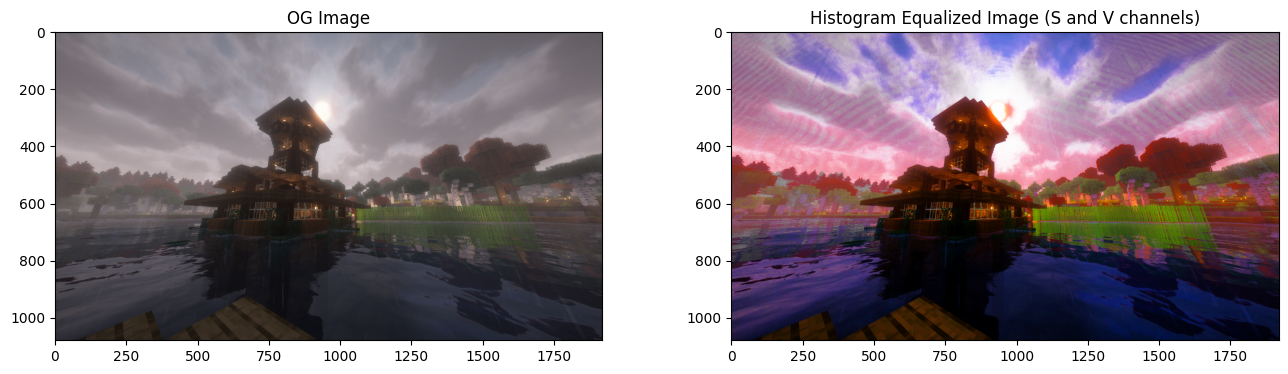

In [79]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('OG Image')
plt.imshow(newImg_RGB)
plt.subplot(1,2,2)
plt.title('Histogram Equalized Image (S and V channels)')
plt.imshow(histEqSV_Img)
plt.show()

# Kết quả sau khi áp dụng histogram equalization chỉ trên 2 kênh S và V nhưng vẫn giữ được màu sắc gốc (Hue) thì ảnh vẫn có thay đổi về các chi tiết như độ sáng, độ tương phản (cảm giác các chi tiết trong ảnh được làm nổi bật hơn so với ảnh gốc, nhưng thay đổi màu sắc)
# => Ảnh vẫn giữ được màu sắc gốc nhưng không rực rỡ và sống động như khi áp dụng trên cả 3 kênh HSV

Implement a function to perform histogram matching between two images: one as the source and another as the reference.

💡 Hint: You may use cv2.calcHist, cv2.LUT(), or skimage.exposure.match_histograms.


In [80]:
# Ideas: https://scikit-image.org/docs/0.25.x/auto_examples/color_exposure/plot_histogram_matching.html

def histogramMatching(sourceImg, copyImg):
    # 'channel_axis=-1' (hoặc multichannel=True trong phiên bản cũ)
    matched_image = exposure.match_histograms(sourceImg, copyImg, channel_axis=-1)
    
    return matched_image

secImg_BGR = cv2.imread('base2.png')
secImg_RGB = cv2.cvtColor(secImg_BGR, cv2.COLOR_BGR2RGB)

matched_Img = histogramMatching(newImg_RGB, secImg_RGB)


## 6. Create a binary mask using the following approaches (Please choose another external image and indicate whether the object can be separated or not.):
- Based on a specific color channel (R, G, or B) condition.
- Based on intensity thresholds in HSV channels (Hue, Saturation, Value).
- Based on combined conditions (e.g., R > 200 AND G < 50).

Apply the mask to the original image in order to extract the target object.

In [81]:

maskImg_BGR = cv2.imread('mask.png')
maskImg_RGB = cv2.cvtColor(maskImg_BGR, cv2.COLOR_BGR2RGB)

def applyMask(originalImg, maskImg):
    # Đảm bảo mask là binary
    grayMask = cv2.cvtColor(maskImg, cv2.COLOR_RGB2GRAY)
    _, binaryMask = cv2.threshold(grayMask, 127, 255, cv2.THRESH_BINARY)

    # Thực hiện áp dụng mask
    mask = cv2.bitwise_and(originalImg, originalImg, mask=binaryMask)

    return mask

def createMaskColor(image, color, threshold):
    if color == 'R':
        channel = image[:, :, 0]
    elif color == 'G':
        channel = image[:, :, 1]
    elif color == 'B':
        channel = image[:, :, 2]
    
    _, mask = cv2.threshold(channel, threshold, 255, cv2.THRESH_BINARY)
    return mask
def createMaskHSV(image, h_range, s_range, v_range):
    hsvImg = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsvImg)

    h_mask = cv2.inRange(h, h_range[0], h_range[1])
    s_mask = cv2.inRange(s, s_range[0], s_range[1])
    v_mask = cv2.inRange(v, v_range[0], v_range[1])

    mask = cv2.bitwise_and(h_mask, cv2.bitwise_and(s_mask, v_mask))
    return mask
def createMaskCombined(image, r_cap, g_cap):
    r_channel = image[:, :, 0]
    g_channel = image[:, :, 1]

    r_mask = cv2.inRange(r_channel, r_cap[0], r_cap[1])
    g_mask = cv2.inRange(g_channel, g_cap[0], g_cap[1])

    mask = cv2.bitwise_and(r_mask, g_mask)
    return mask
# Create mask
mask_R = createMaskColor(maskImg_RGB, 'R', 200)
mask_G = createMaskColor(maskImg_RGB, 'G', 200)
mask_B = createMaskColor(maskImg_RGB, 'B', 200)
mask_HSV = createMaskHSV(maskImg_RGB, (0, 50), (100, 255), (100, 255))
mask_Combined = createMaskCombined(maskImg_RGB, (200, 255), (0, 50))
# Apply mask
masked_R = applyMask(maskImg_RGB, cv2.cvtColor(mask_R, cv2.COLOR_GRAY2RGB))
masked_G = applyMask(maskImg_RGB, cv2.cvtColor(mask_G, cv2.COLOR_GRAY2RGB))
masked_B = applyMask(maskImg_RGB, cv2.cvtColor(mask_B, cv2.COLOR_GRAY2RGB))
masked_HSV = applyMask(maskImg_RGB, cv2.cvtColor(mask_HSV, cv2.COLOR_GRAY2RGB))
masked_Combined = applyMask(maskImg_RGB, cv2.cvtColor(mask_Combined, cv2.COLOR_GRAY2RGB))




## 7. Report
* Display the original image and all processed results (after each transformation).
* Provide a brief commentary describing and comparing the visual differences observed between the methods.

### 7.1.1. Display the original image and all processed results (after each transformation).

Apply Gamma Correction and Logarithmic Transformation to improve the image contrast.

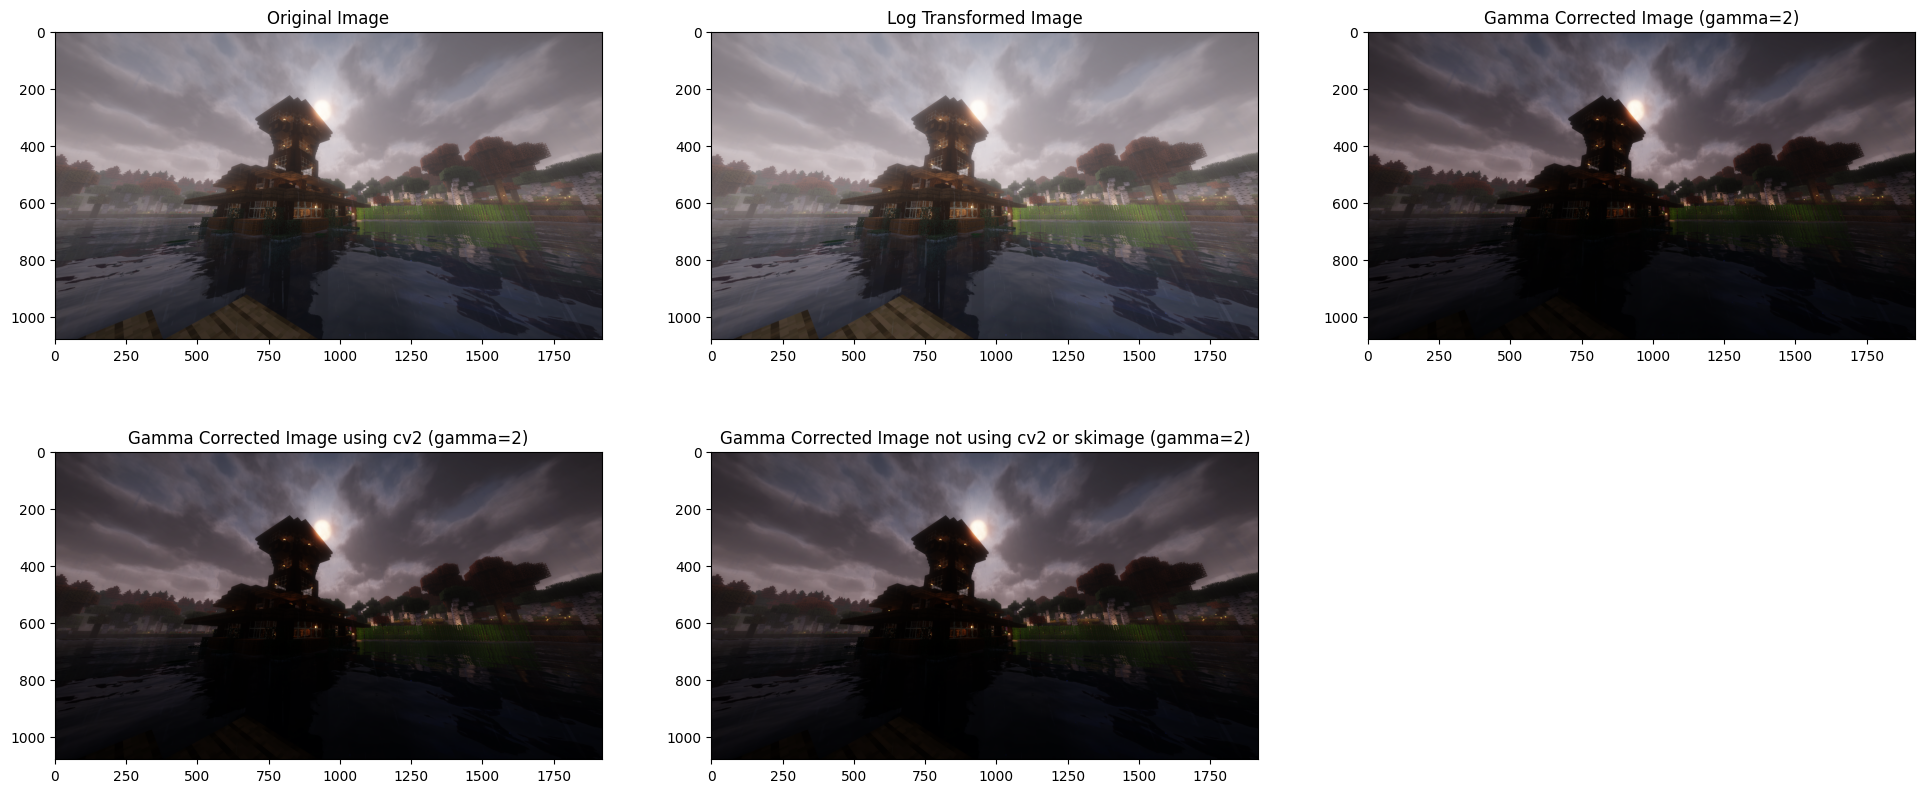

In [82]:
# Display the results
plt.figure(figsize=(24, 10))
plt.subplot(2, 3, 1)
plt.title('Original Image')
plt.imshow(newImg_RGB)
plt.subplot(2, 3, 2)
plt.title('Log Transformed Image')
plt.imshow(logTransformed_Img)
plt.subplot(2, 3, 3)
plt.title('Gamma Corrected Image (gamma=2)')
plt.imshow(gammaCorrected_Img)
plt.subplot(2, 3, 4)
plt.title('Gamma Corrected Image using cv2 (gamma=2)')
plt.imshow(gammaCorrected_Img_cv2)
plt.subplot(2, 3, 5)
plt.title('Gamma Corrected Image not using cv2 or skimage (gamma=2)')
plt.imshow(gammaCorrected_Img_gigachad)
plt.show()

Combine Gamma + Logarithmic Correction sequentially

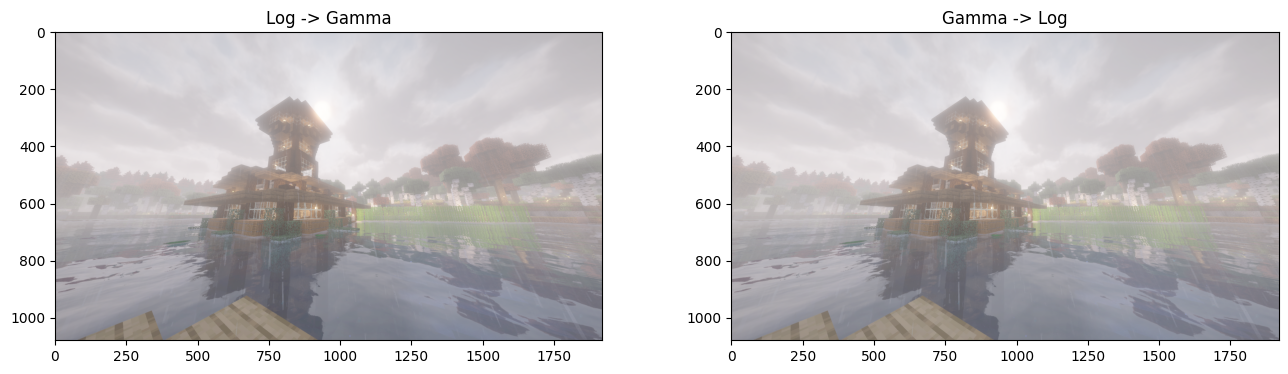

In [83]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('Log -> Gamma')
plt.imshow(logGamma_Img)
plt.subplot(1,2,2)
plt.title('Gamma -> Log')
plt.imshow(gammaLog_Img)
plt.show()

Optimal gamma value

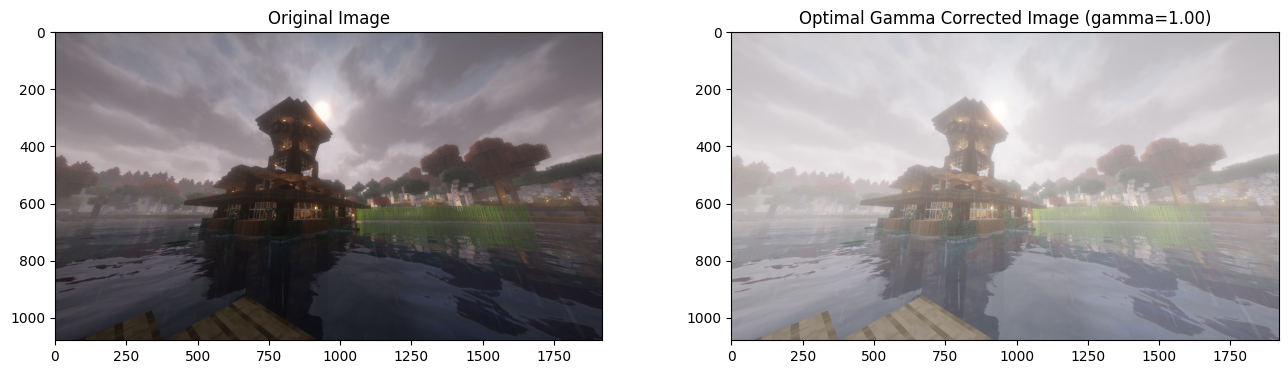

In [84]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(newImg_RGB)
plt.subplot(1,2,2)
plt.title(f'Optimal Gamma Corrected Image (gamma={optGamma:.2f})')
plt.imshow(optGamma_Img)
plt.show()

Apply histogram equalization independently on all three HSV channels (Hue, Saturation, Value)

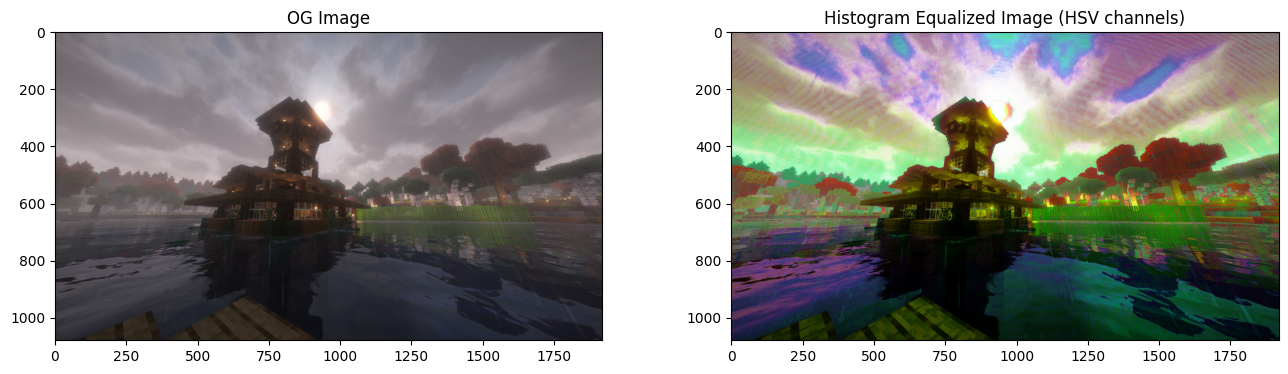

In [85]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('OG Image')
plt.imshow(newImg_RGB)
plt.subplot(1,2,2)
plt.title('Histogram Equalized Image (HSV channels)')
plt.imshow(histEq_Img)
plt.show()

Apply histogram equalization only on the S (Saturation) and V (Value) channels to enhance image quality while preserving hue.

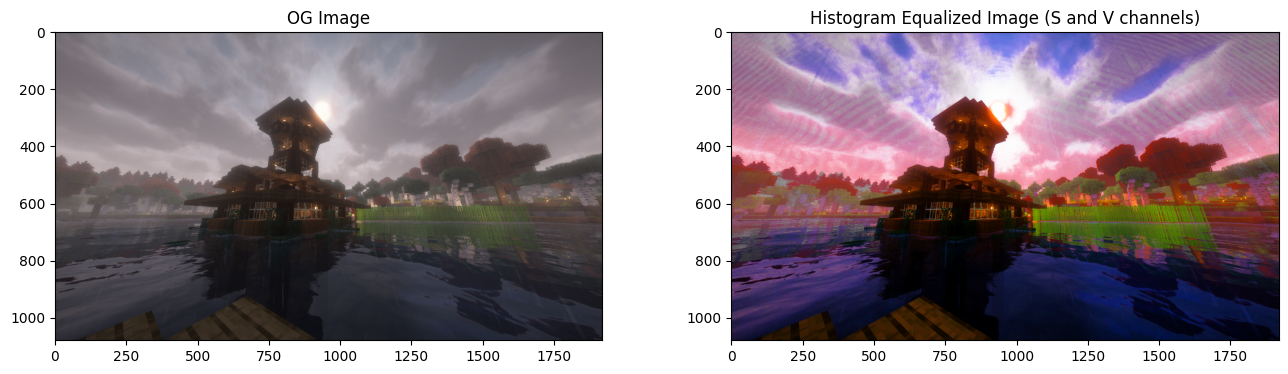

In [86]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.title('OG Image')
plt.imshow(newImg_RGB)
plt.subplot(1,2,2)
plt.title('Histogram Equalized Image (S and V channels)')
plt.imshow(histEqSV_Img)
plt.show()

Histogram matching between two images

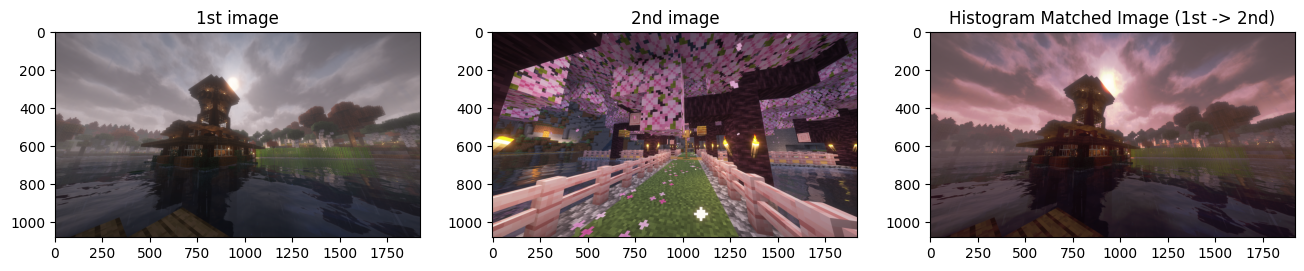

In [87]:
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.title('1st image')
plt.imshow(newImg_RGB)
plt.subplot(1,3,2)
plt.title('2nd image')
plt.imshow(secImg_RGB)
plt.subplot(1,3,3)
plt.title('Histogram Matched Image (1st -> 2nd)')
plt.imshow(matched_Img)
plt.show()

Binary mask (Based on specific color channel (R, G, or B) condition)

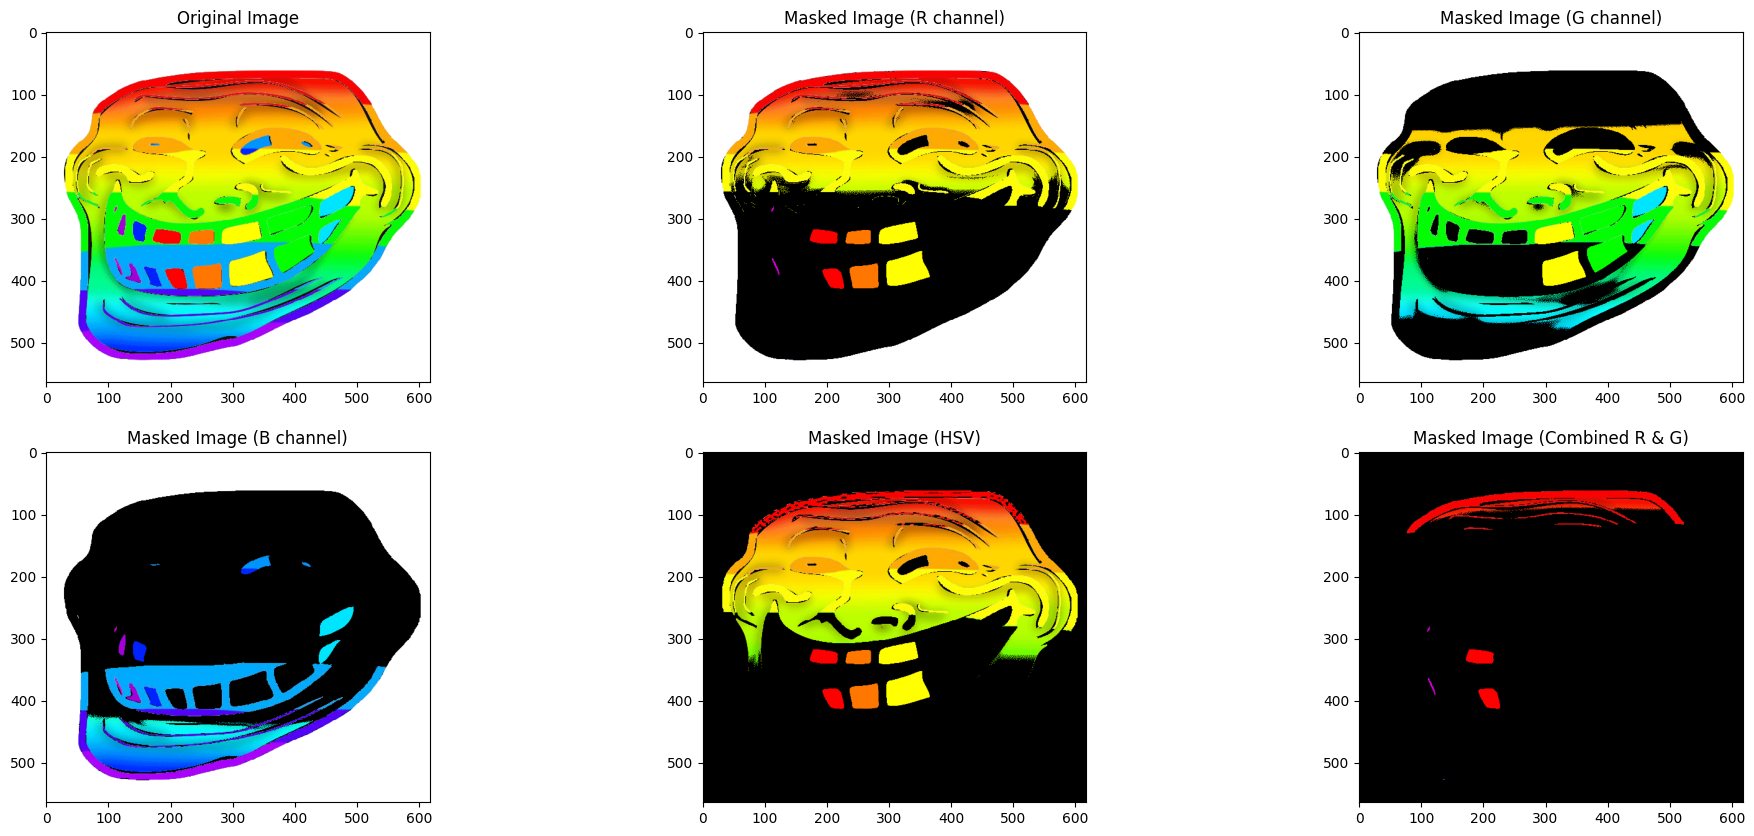

In [88]:
# # Show results
# Based on specific color channel (R, G, or B) condition

plt.figure(figsize=(24, 10))
plt.subplot(2, 3, 1)
plt.title('Original Image')
plt.imshow(maskImg_RGB)
plt.subplot(2, 3, 2)
plt.title('Masked Image (R channel)')
plt.imshow(masked_R)
plt.subplot(2, 3, 3)
plt.title('Masked Image (G channel)')
plt.imshow(masked_G)
plt.subplot(2, 3, 4)
plt.title('Masked Image (B channel)')
plt.imshow(masked_B)
plt.subplot(2, 3, 5)
plt.title('Masked Image (HSV)')
plt.imshow(masked_HSV)
plt.subplot(2, 3, 6)
plt.title('Masked Image (Combined R & G)')
plt.imshow(masked_Combined)
plt.show()


### 7.1.2. Provide a brief commentary describing and comparing the visual differences observed between the methods.

> Gamma and Logarithmic Correction


Gamma correction làm tăng độ sáng của các vùng tối trong ảnh, giúp làm nổi bật các chi tiết ẩn trong bóng tối. 

Ngược lại, Logarithmic làm tăng độ sáng của các vùng sáng, giúp làm nổi bật các chi tiết trong các vùng sáng.

Khi kết hợp cả hai phương pháp, ta có thể tận dụng ưu điểm của cả hai để cải thiện độ tương phản tổng thể của ảnh. Tuy nhiên, thứ tự áp dụng hai phương pháp này cũng ảnh hưởng đến kết quả cuối cùng. Áp dụng logarithmic transformation trước gamma correction thường mang lại kết quả tốt hơn trong việc cân bằng độ sáng và độ tương phản của ảnh.


> Histogram Equalization

Histogram Equalization là một phương pháp cải thiện độ tương phản của ảnh bằng cách phân phối lại cường độ sáng của các pixel trong ảnh. Phương pháp này hoạt động bằng cách tạo ra một histogram (biểu đồ tần suất) của các giá trị pixel trong ảnh gốc, sau đó điều chỉnh các giá trị này để tạo ra một histogram mới với phân phối đồng đều hơn.

+ Khi áp dụng Histogram Equalization trên cả 3 kênh HSV (Hue, Saturation, Value), ảnh đầu ra thường có độ tương phản cao hơn và các chi tiết trong ảnh được làm nổi bật rõ ràng hơn so với ảnh gốc. Điều này làm cho ảnh trở nên rực rỡ và sống động hơn, tuy nhiên cũng có thể dẫn đến việc mất đi một số chi tiết nhỏ trong quá trình điều chỉnh.

+ Ngược lại, khi chỉ áp dụng Histogram Equalization trên 2 kênh S và V (Saturation và Value) trong không gian màu HSV, ảnh đầu ra vẫn giữ được màu sắc gốc (Hue) của ảnh ban đầu. Mặc dù độ tương phản và độ sáng của ảnh vẫn được cải thiện, nhưng hiệu ứng rực rỡ và sống động không rõ rệt như khi áp dụng trên cả 3 kênh. Phương pháp này thích hợp khi người dùng muốn duy trì màu sắc tự nhiên của ảnh trong khi vẫn cải thiện chất lượng hình ảnh.



> Histogram matching

Histogram matching giúp điều chỉnh histogram của ảnh nguồn sao cho giống với histogram của ảnh mục tiêu. Kết quả là ảnh nguồn sẽ có độ sáng và độ tương phản tương tự như ảnh mục tiêu.
 
Khi so sánh ảnh gốc và ảnh sau khi áp dụng histogram matching, ta có thể thấy rằng ảnh sau khi áp dụng có độ sáng và độ tương phản được cải thiện, làm nổi bật các chi tiết trong ảnh. Điều này đặc biệt hữu ích khi ảnh gốc có độ sáng thấp hoặc thiếu độ tương phản.


> Binary Mask

Bỉnary Mask là một kỹ thuật trong xử lý ảnh dùng để tách đối tượng mục tiêu khỏi nền. Mặt nạ này xác định các pixel thuộc về đối tượng mục tiêu (giá trị 1 hoặc trắng) và các pixel thuộc về nền (giá trị 0 hoặc đen).

Ảnh sau khi áp dụng binary mask giúp làm nổi bật đối tượng mục tiêu một cách rõ ràng theo yêu cầu tự chọn
